In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:

df_add_cart = pd.read_parquet("add_to_cart.parquet")
print(df_add_cart.head())
print(f"This is the size of the add cart: {df_add_cart.size}")

   client_id            timestamp      sku
0   18080713  2022-08-06 15:17:25   219064
1    8081030  2022-09-19 17:45:25  1375125
2    4480154  2022-12-06 06:35:15  1291128
3    3411058  2022-11-21 21:50:30  1523102
4   10551361  2022-09-22 06:26:40   728970
This is the size of the add cart: 22623351


In [4]:

df_page_visit = pd.read_parquet("page_visit.parquet")
print(df_page_visit.head())
print(f"This is the size of the page visit: {df_page_visit.size}")

   client_id            timestamp      url
0   19155437  2022-07-13 10:37:45  2310881
1   19155437  2022-08-11 18:13:20   952215
2   15175374  2022-07-25 09:47:10  5409374
3   15175374  2022-10-06 07:57:55  3036169
4   15175374  2022-10-06 07:58:55  3036169
This is the size of the page visit: 598355940


In [5]:

df_product_buy = pd.read_parquet("product_buy.parquet")
print(df_product_buy.head())
print(f"This is the size of the product buy : {df_product_buy.size}")

   client_id            timestamp      sku
0   14534769  2022-07-07 20:03:10    91300
1   14534769  2022-12-02 12:32:05   660194
2    4480154  2022-12-06 06:38:20  1291128
3    3411058  2022-11-21 21:47:35  1523102
4   10551361  2022-09-22 06:28:20   728970
This is the size of the product buy : 6955506


In [6]:
df_product_properties = pd.read_parquet("product_properties.parquet")
print(df_product_properties.head())
print(f"This is the size of the see product properties: {df_product_properties.size}")

       sku  category  price                                               name
0  1263699       780     26  [193 102 221  13  57 176  57  99 169  14 242  ...
1   742320      4220     64  [ 95 172 124 189 137 196 226  95 237 124   1 1...
2  1201131      2243     37  [187 187 187 187 187 187 187 187 187 187 187 1...
3   167164      3130     38  [125 189 171 189 186 207  42  31 113 219 221 1...
4  1350853      3863     85  [175  21   3 157  93  71 123  76  57  95 235  ...
This is the size of the see product properties: 6136200


In [7]:
df_remove_from_cart = pd.read_parquet("remove_from_cart.parquet")
print(df_remove_from_cart.head())
print(f"This is the size of removing a thing of cart: {df_remove_from_cart.size}")

   client_id            timestamp     sku
0    4480154  2022-12-06 06:35:30  551275
1   10551361  2022-09-22 06:26:55  728970
2   10551361  2022-10-15 20:20:05  655683
3   10522335  2022-08-06 09:23:15  606762
4   10522335  2022-08-06 09:23:20  606762
This is the size of removing a thing of cart: 8066682


In [8]:
df_search_query = pd.read_parquet("search_query.parquet")
print(df_search_query.head())
print(f"This is the size of the add cart: {df_search_query.size}")

   client_id            timestamp  \
0   14554694  2022-10-15 20:06:40   
1   14554694  2022-10-15 20:07:00   
2    2406455  2022-07-12 06:15:30   
3   11556051  2022-06-29 08:05:55   
4   11556051  2022-06-29 08:06:00   

                                               query  
0  [240 170 240 207 251 138  16 169 162 254 170 1...  
1  [174  61  58 154 154  57 102 102 195 167  68  ...  
2  [250 172  48  48   7 122 145 116  60 122 204 2...  
3  [251   0  96 230 142  99  70 204 113 150 228  ...  
4  [ 60 185 170 134 246  75   8 232 113 113 228 1...  
This is the size of the add cart: 39671307


In [9]:
product_add_cart_timestamps = df_add_cart["timestamp"]

page_visit_timestamps = df_page_visit["timestamp"]

product_buy_timestamps = df_product_buy["timestamp"]

product_remove_cart_timestamps = df_remove_from_cart["timestamp"]

product_search_query = df_search_query["timestamp"]


print(f"Product add to cart ts {product_add_cart_timestamps[0]}")

print(f"Page visited ts {page_visit_timestamps[0]}")

print(f"product bought ts {product_buy_timestamps[0]}")

print(f"product remove from cart ts {product_remove_cart_timestamps[0]}")

print(f"product searched ts {product_search_query[0]}")




Product add to cart ts 2022-08-06 15:17:25
Page visited ts 2022-07-13 10:37:45
product bought ts 2022-07-07 20:03:10
product remove from cart ts 2022-12-06 06:35:30
product searched ts 2022-10-15 20:06:40


In [10]:
df_add_cart["ts_unix"] = pd.to_datetime(df_add_cart["timestamp"]).astype("int64") // 10**9
df_page_visit["ts_unix"] = pd.to_datetime(df_page_visit["timestamp"]).astype("int64") // 10**9
df_product_buy["ts_unix"] = pd.to_datetime(df_product_buy["timestamp"]).astype("int64") // 10**9
df_remove_from_cart["ts_unix"] = pd.to_datetime(df_remove_from_cart["timestamp"]).astype("int64") // 10 ** 9
df_search_query["ts_unix"] = pd.to_datetime(df_search_query["timestamp"]).astype("int64") // 10 ** 9

In [ ]:
events_per_user_add_to_cart = df_add_cart["client_id"].value_counts()
print("Median events_per_user_add_to_cart:", events_per_user_add_to_cart.median())
print("Mean events_per_user_add_to_cart:", events_per_user_add_to_cart.mean())


"""
1)  The usesrs are maybe the same between the same events, == client id == the same between data set we can combine it... to work with the same data set
- Avaibable 
2)  Rocket, maybe the event, user data set == maybe filter out all the use , less than 2 events or 3 events, how many events will have after that
    Possibility, possible to use it, learn about user behaviour, click so maybe, we have a lot of data unless
    Double check the data sets and try to see of their challange, graph in the synrise, universal behaviour
    Collect all the 5 users, use 1,000,000 million users == median and mean combine per user, to millon 
    
    
    1 - Event(Rocket leave it, Otto Leave it) and working == Synirese,)
    
    Read rocket look weather. mistaking that how I extract the client id together, many user few events(only to have time), is the right now
"""

Median events_per_user_add_to_cart: 1.0
Mean events_per_user_add_to_cart: 3.2317276939895767


In [12]:
events_per_user_page_visit = df_page_visit["client_id"].value_counts()
print("Median events_per_user_page_visit:", events_per_user_page_visit.median())
print("Mean events_per_user_page_visit:", events_per_user_page_visit.mean())

Median events_per_user_page_visit: 2.0
Mean events_per_user_page_visit: 9.06847313526172


In [13]:
events_per_user_product_buy = df_product_buy["client_id"].value_counts()
print("Median events_per_user_product_buy:", events_per_user_product_buy.median())
print("Mean events_per_user_product_buy:", events_per_user_product_buy.mean())

Median events_per_user_product_buy: 2.0
Mean events_per_user_product_buy: 2.5500181476226613


In [14]:
events_per_user_remove_product_from_cart = df_remove_from_cart["client_id"].value_counts()
print("Median events_per_user_remove_product_from_cart:", events_per_user_remove_product_from_cart.median())
print("Mean events_per_user_remove_product_from_cart:", events_per_user_remove_product_from_cart.mean())

Median events_per_user_remove_product_from_cart: 2.0
Mean events_per_user_remove_product_from_cart: 3.872305372621477


In [15]:
events_per_user_search_query = df_search_query["client_id"].value_counts()
print("Median events_per_user_search_query:", events_per_user_search_query.median())
print("Mean events_per_user_search_query:", events_per_user_search_query.mean())

Median events_per_user_search_query: 3.0
Mean events_per_user_search_query: 8.115495011497766


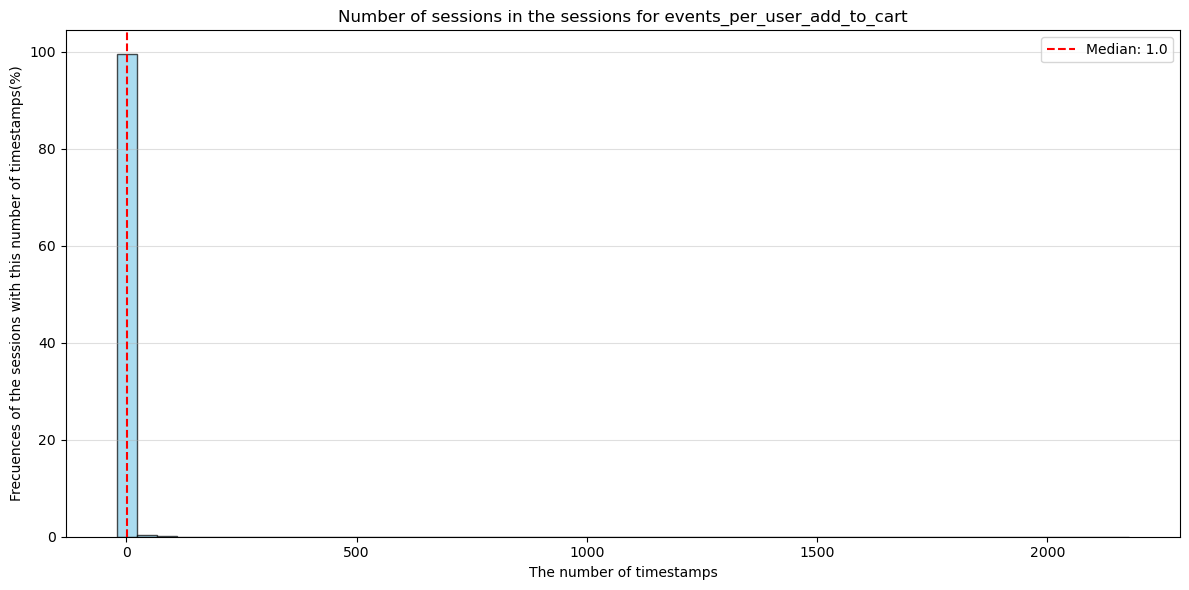

In [17]:
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(events_per_user_add_to_cart, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )


counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(events_per_user_add_to_cart.median(), color="red", linestyle="--", label=f"Median: {events_per_user_add_to_cart.median()}")
plt.title("Number of sessions in the sessions for events_per_user_add_to_cart")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

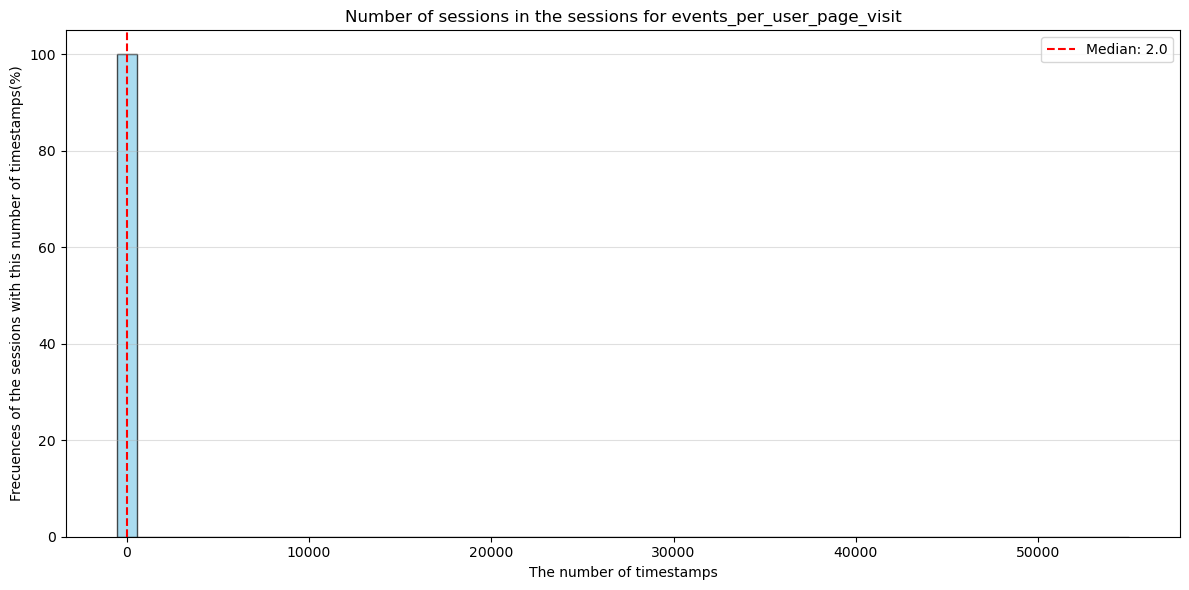

In [18]:
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(events_per_user_page_visit, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )


counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(events_per_user_page_visit.median(), color="red", linestyle="--", label=f"Median: {events_per_user_page_visit.median()}")
plt.title("Number of sessions in the sessions for events_per_user_page_visit")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

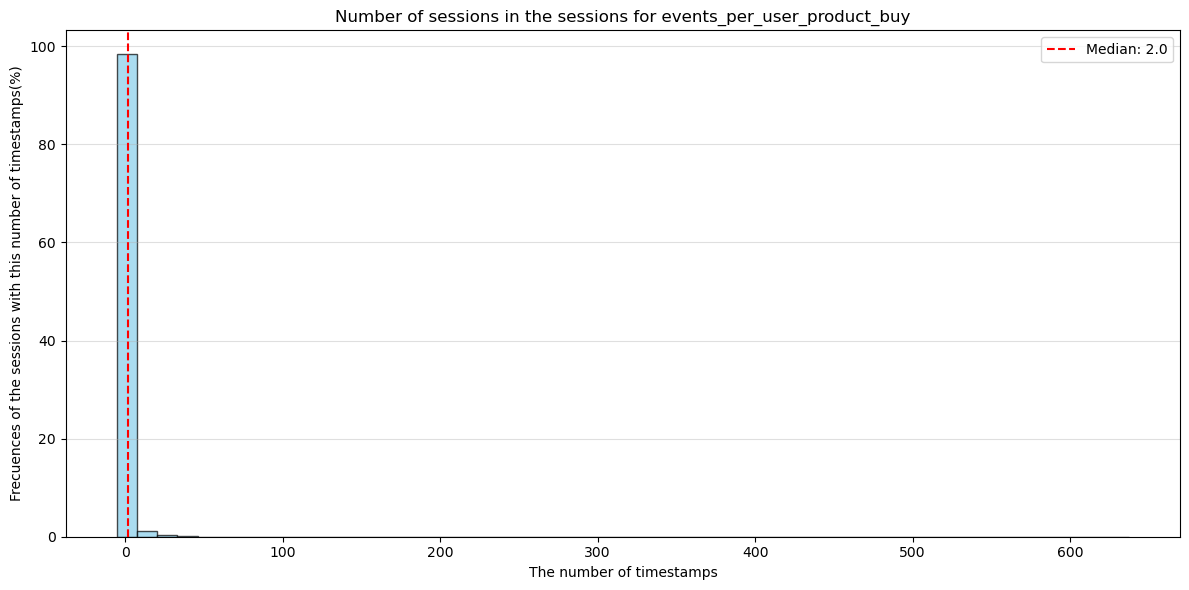

In [20]:
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(events_per_user_product_buy, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )


counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(events_per_user_product_buy.median(), color="red", linestyle="--", label=f"Median: {events_per_user_product_buy.median()}")
plt.title("Number of sessions in the sessions for events_per_user_product_buy")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

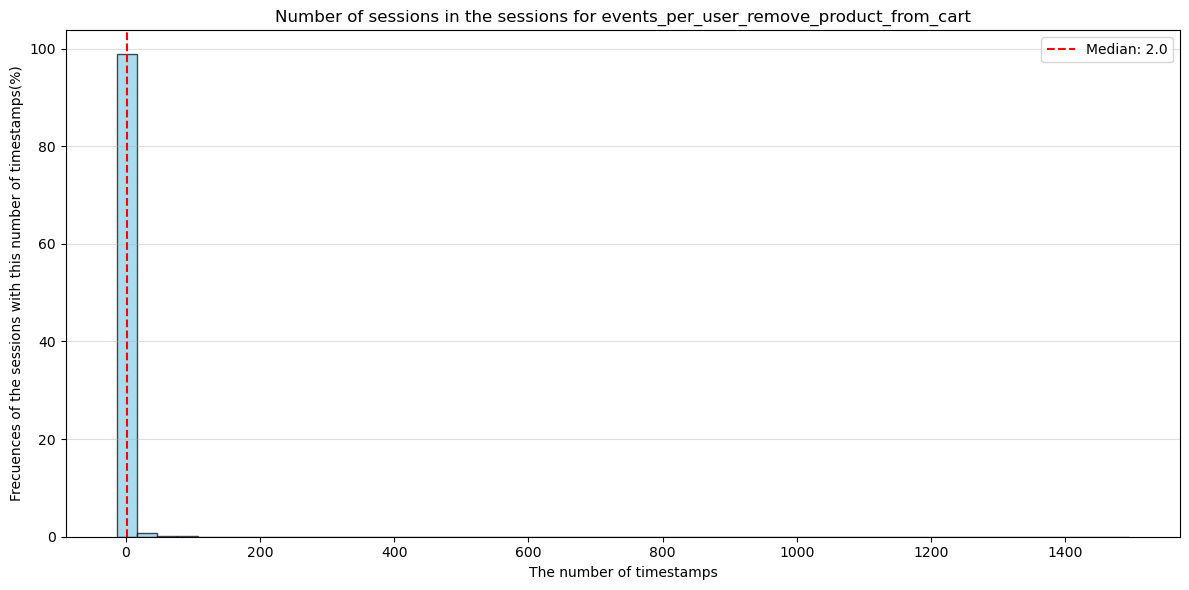

In [21]:
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(events_per_user_remove_product_from_cart, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )


counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(events_per_user_remove_product_from_cart.median(), color="red", linestyle="--", label=f"Median: {events_per_user_remove_product_from_cart.median()}")
plt.title("Number of sessions in the sessions for events_per_user_remove_product_from_cart")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

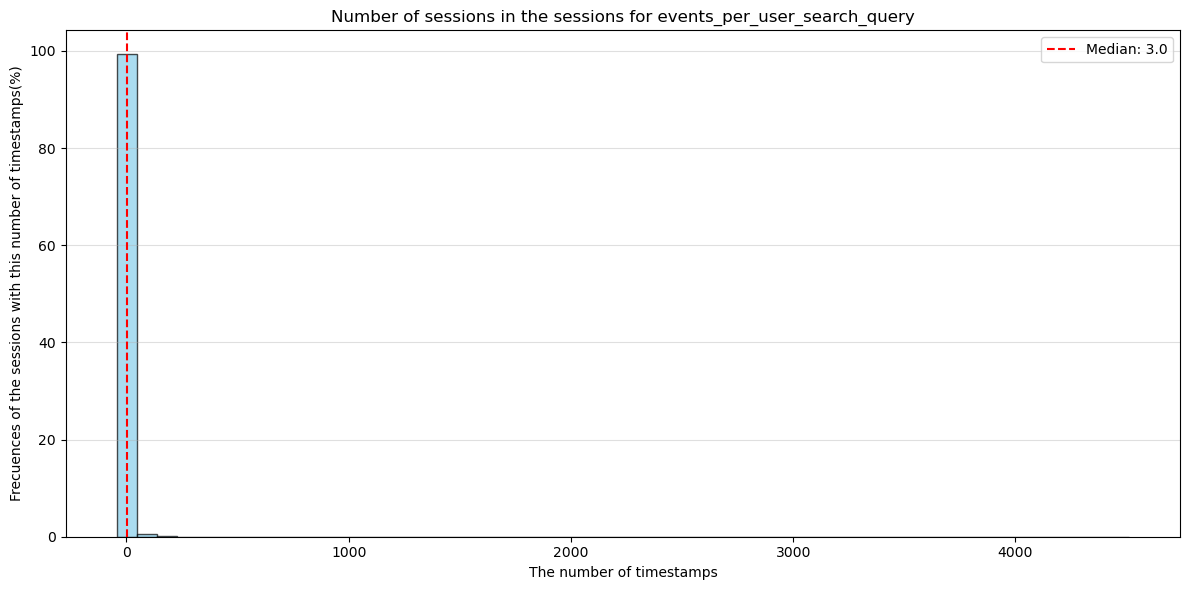

In [22]:
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(events_per_user_search_query, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )


counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(events_per_user_search_query.median(), color="red", linestyle="--", label=f"Median: {events_per_user_search_query.median()}")
plt.title("Number of sessions in the sessions for events_per_user_search_query")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()